In [160]:
import mysql.connector
import pandas as pd

cnx = mysql.connector.connect(
    host="127.0.0.1",
    port=3306,
    user="root",
    password="cscorner")

In [161]:
query = "SELECT * FROM loan_case.customer" 

In [162]:
df = pd.read_sql(query, cnx)

C:\Users\diont\AppData\Local\Temp\ipykernel_16824\1600954950.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cnx)


In [163]:
cnx.close()

In [165]:
df.head(5)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110,360,1,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126,360,1,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208,360,1,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100,360,,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78,360,1,Urban


In [169]:
df.describe

<bound method NDFrame.describe of       Loan_ID Gender Married  Dependents     Education Self_Employed  \
0    LP001015   Male     Yes           0      Graduate            No   
1    LP001022   Male     Yes           1      Graduate            No   
2    LP001031   Male     Yes           2      Graduate            No   
3    LP001035   Male     Yes           2      Graduate            No   
4    LP001051   Male      No           0  Not Graduate            No   
..        ...    ...     ...         ...           ...           ...   
303  LP002969   Male     Yes           1      Graduate            No   
304  LP002975   Male     Yes           0      Graduate            No   
305  LP002980   Male      No           0      Graduate            No   
306  LP002986   Male     Yes           0      Graduate            No   
307  LP002989   Male      No           0      Graduate           Yes   

     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0               5720        

In [171]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Loan_ID            308 non-null    object
 1   Gender             308 non-null    object
 2   Married            308 non-null    object
 3   Dependents         308 non-null    int64 
 4   Education          308 non-null    object
 5   Self_Employed      308 non-null    object
 6   ApplicantIncome    308 non-null    int64 
 7   CoapplicantIncome  308 non-null    int64 
 8   LoanAmount         308 non-null    int64 
 9   Loan_Amount_Term   308 non-null    int64 
 10  Credit_History     308 non-null    object
 11  Property_Area      308 non-null    object
dtypes: int64(5), object(7)
memory usage: 29.0+ KB


In [174]:
df['ApplicantIncome'].min()

0

In [176]:
df['ApplicantIncome'].max()

32000

In [178]:
df['LoanAmount'].mean()  

135.50974025974025

In [180]:
df['Credit_History'].value_counts() 

Credit_History
1    239
0     48
      21
Name: count, dtype: int64

In [182]:
df.isnull().sum()    # Shows how many nulls in each column

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64

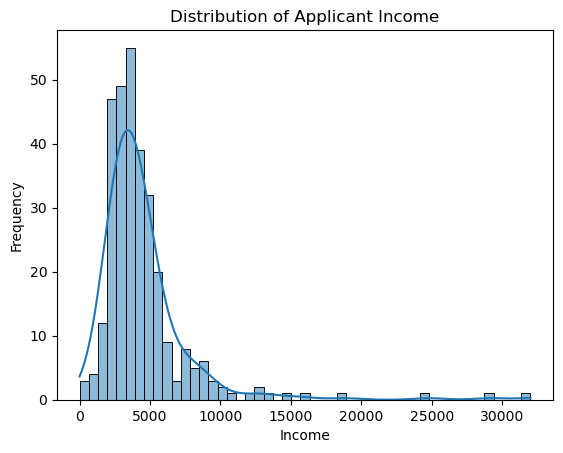

In [184]:
import matplotlib.pyplot as plt
import seaborn as sns


# Histogram of Applicant Income
sns.histplot(df['ApplicantIncome'], kde=True)
plt.title('Distribution of Applicant Income')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.show()


# The histogram below shows the distribution of Applicant Income across all loan applicants.

# The distribution is right-skewed, meaning that most applicants have lower to moderate incomes,
# while a small number of applicants have very high incomes (outliers).

# The peak (mode) of the distribution lies in the lower income range (likely under $5,000–$6,000), 
# suggesting that the majority of applicants fall within this income bracket

In [185]:
df.shape              

(308, 12)

In [186]:
df.columns           

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='object')

In [190]:
df.dtypes             

Loan_ID              object
Gender               object
Married              object
Dependents            int64
Education            object
Self_Employed        object
ApplicantIncome       int64
CoapplicantIncome     int64
LoanAmount            int64
Loan_Amount_Term      int64
Credit_History       object
Property_Area        object
dtype: object

In [192]:
df.describe(include='all')  

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
count,308,308,308,308.000000,308,308,308.000000,308.000000,308.000000,308.000000,308,308
unique,308,3,2,NaN,2,3,NaN,NaN,NaN,NaN,3,3
top,LP001015,Male,Yes,NaN,Graduate,No,NaN,NaN,NaN,NaN,1,Urban
freq,1,238,185,NaN,242,256,NaN,NaN,NaN,NaN,239,114
mean,NaN,NaN,NaN,0.558442,NaN,NaN,4501.594156,1645.698052,135.509740,343.935065,NaN,NaN
std,NaN,NaN,NaN,0.794829,NaN,NaN,3413.564827,2463.533959,60.239289,62.945059,NaN,NaN
min,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000,0.000000,28.000000,6.000000,NaN,NaN
25%,NaN,NaN,NaN,0.000000,NaN,NaN,2782.000000,0.000000,101.750000,360.000000,NaN,NaN
50%,NaN,NaN,NaN,0.000000,NaN,NaN,3756.000000,1136.000000,125.000000,360.000000,NaN,NaN
75%,NaN,NaN,NaN,1.000000,NaN,NaN,5000.000000,2480.500000,152.750000,360.000000,NaN,NaN


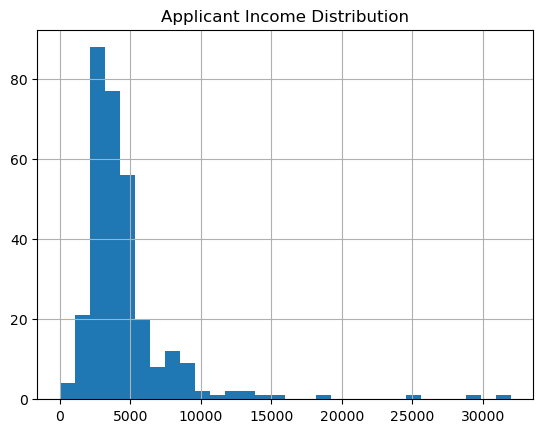

Text(0.5, 1.0, 'Credit History Count')

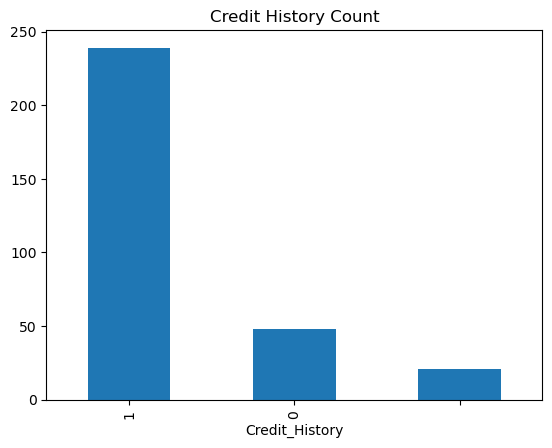

In [194]:
# Numerical
df['ApplicantIncome'].hist(bins=30)
plt.title("Applicant Income Distribution")
plt.show()

# Categorical
df['Credit_History'].value_counts().plot(kind='bar')
plt.title("Credit History Count")

Text(0.5, 1.0, 'Income vs Loan Amount')

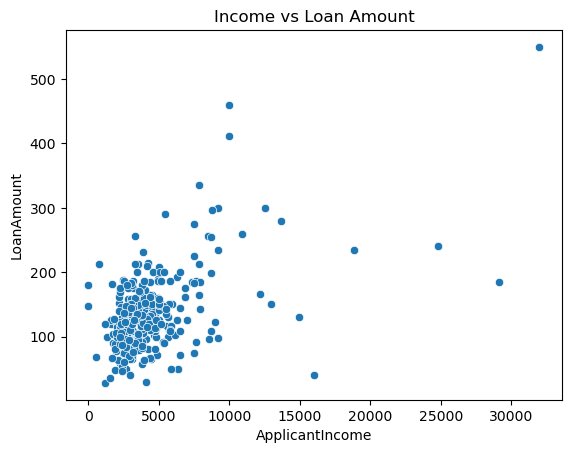

In [195]:
# Income vs Loan Amount
sns.scatterplot(x='ApplicantIncome', y='LoanAmount', data=df)
plt.title("Income vs Loan Amount")

In [197]:
import pandas as pd

loan_status = pd.read_csv("C:/Credit Risk Analysis Project/loan_status.csv")

In [199]:
loan_status.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [202]:
loan_status.shape 

(614, 13)

In [204]:
loan_status.columns 

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [206]:
loan_status.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [208]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='object')

<Axes: xlabel='Credit_History'>

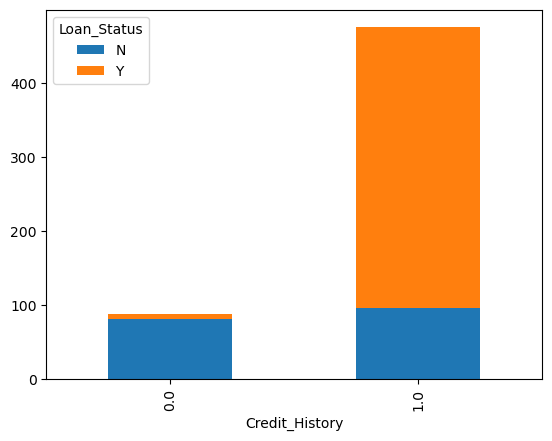

In [210]:
pd.crosstab(loan_status['Credit_History'], loan_status['Loan_Status']).plot(kind='bar', stacked=True)


In [211]:
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df['Income_to_Loan_Ratio'] = df['Total_Income'] / df['LoanAmount']

In [214]:
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

In [216]:
df.groupby('Credit_History')['LoanAmount'].mean()

Credit_History
     131.476190
0    138.458333
1    135.271967
Name: LoanAmount, dtype: float64

In [218]:
df.groupby('Credit_History').size()

Credit_History
      21
0     48
1    239
dtype: int64

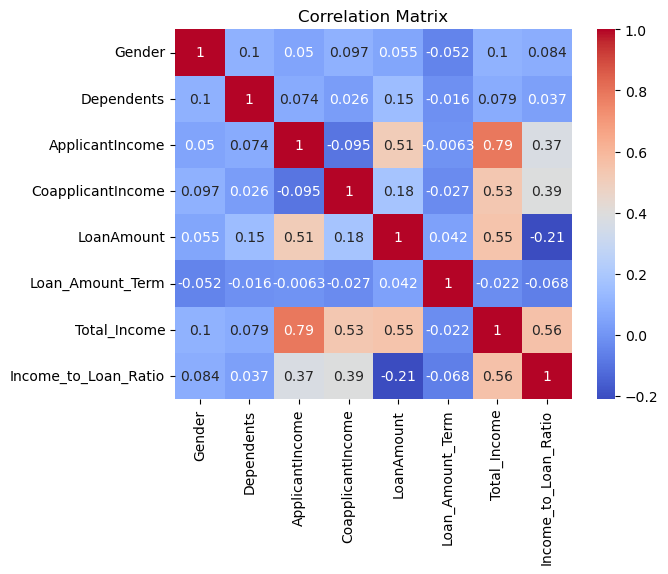

In [220]:
corr_matrix = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [221]:
df.drop(['Loan_ID'], axis=1, inplace=True)


df = pd.get_dummies(df, drop_first=True)

In [222]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

df = loan_status.copy()  # This is your labeled data

# Now continue with model prep
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})
df_encoded = pd.get_dummies(df.drop('Loan_ID', axis=1), drop_first=True)

X = df_encoded.drop('Loan_Status', axis=1)
y = df_encoded['Loan_Status']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("Target values:", y.value_counts())


Shape of X: (614, 14)
Shape of y: (614,)
Target values: Loan_Status
1    422
0    192
Name: count, dtype: int64


In [223]:
X.isnull().sum()

ApplicantIncome             0
CoapplicantIncome           0
LoanAmount                 22
Loan_Amount_Term           14
Credit_History             50
Gender_Male                 0
Married_Yes                 0
Dependents_1                0
Dependents_2                0
Dependents_3+               0
Education_Not Graduate      0
Self_Employed_Yes           0
Property_Area_Semiurban     0
Property_Area_Urban         0
dtype: int64

In [224]:
X = X.fillna(X.median())

In [225]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler

# STEP 1: Scale your data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# STEP 2: Split the data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# STEP 3: Train logistic regression with more iterations
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

# STEP 4: Evaluate
print("Accuracy:", model.score(X_test, y_test))
print("\nClassification Report:\n", classification_report(y_test, model.predict(X_test)))

Accuracy: 0.7886178861788617

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



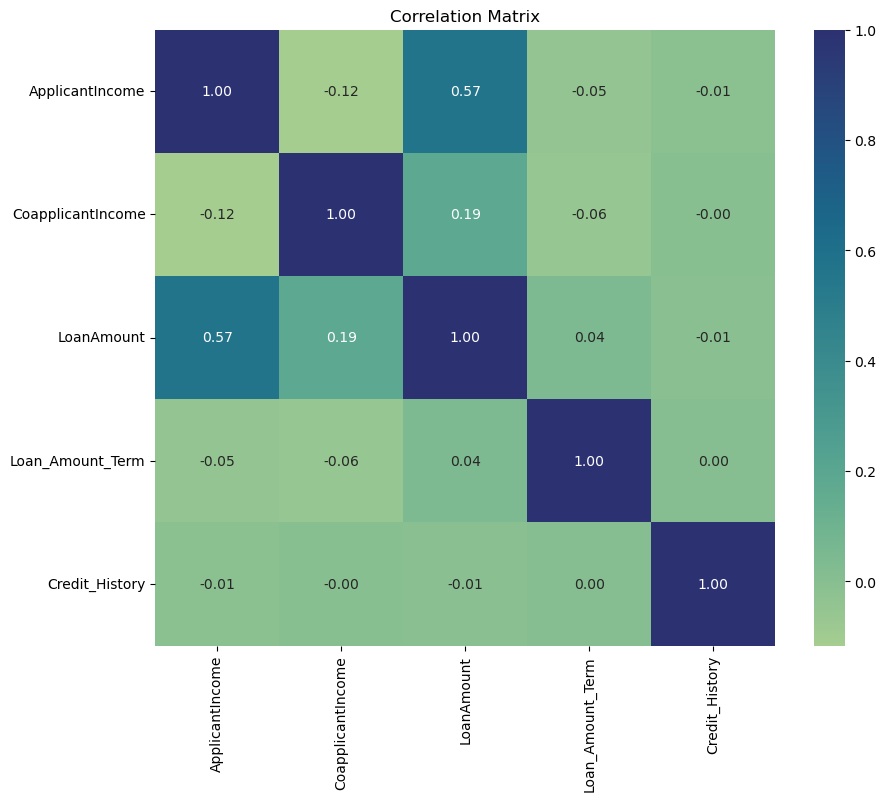

In [227]:
numerical_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
df_numerical = df[numerical_cols]

correlation_matrix = df_numerical.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='crest', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

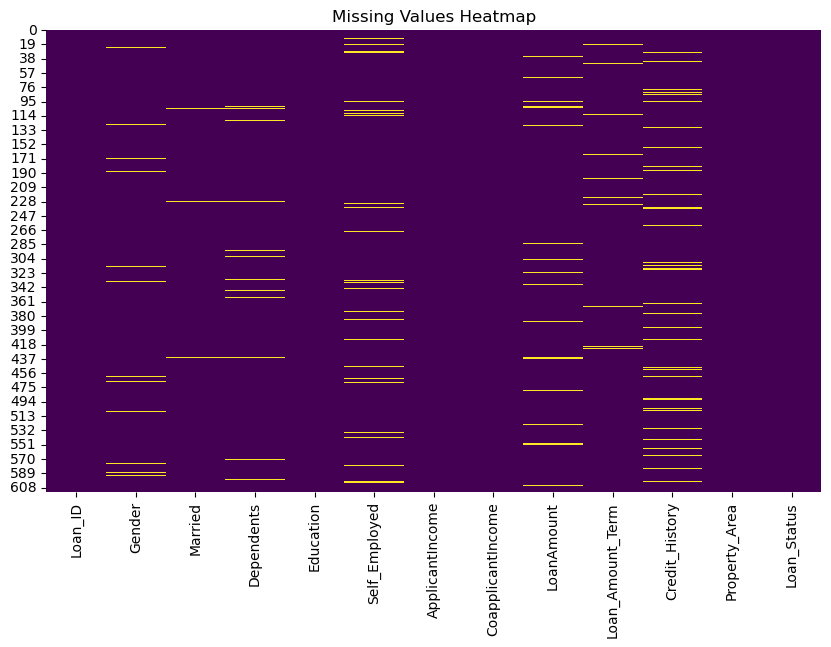

In [233]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

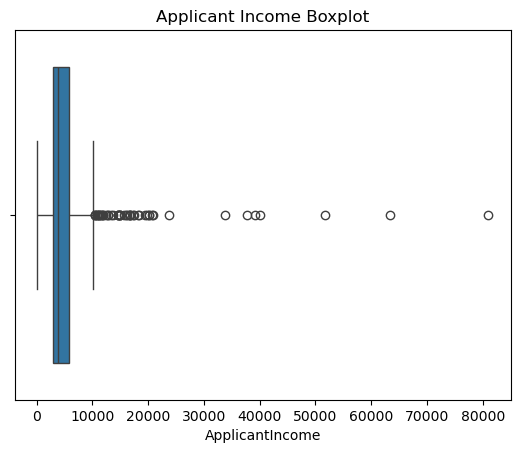

In [234]:
sns.boxplot(x=df['ApplicantIncome'])
plt.title("Applicant Income Boxplot")
plt.show()

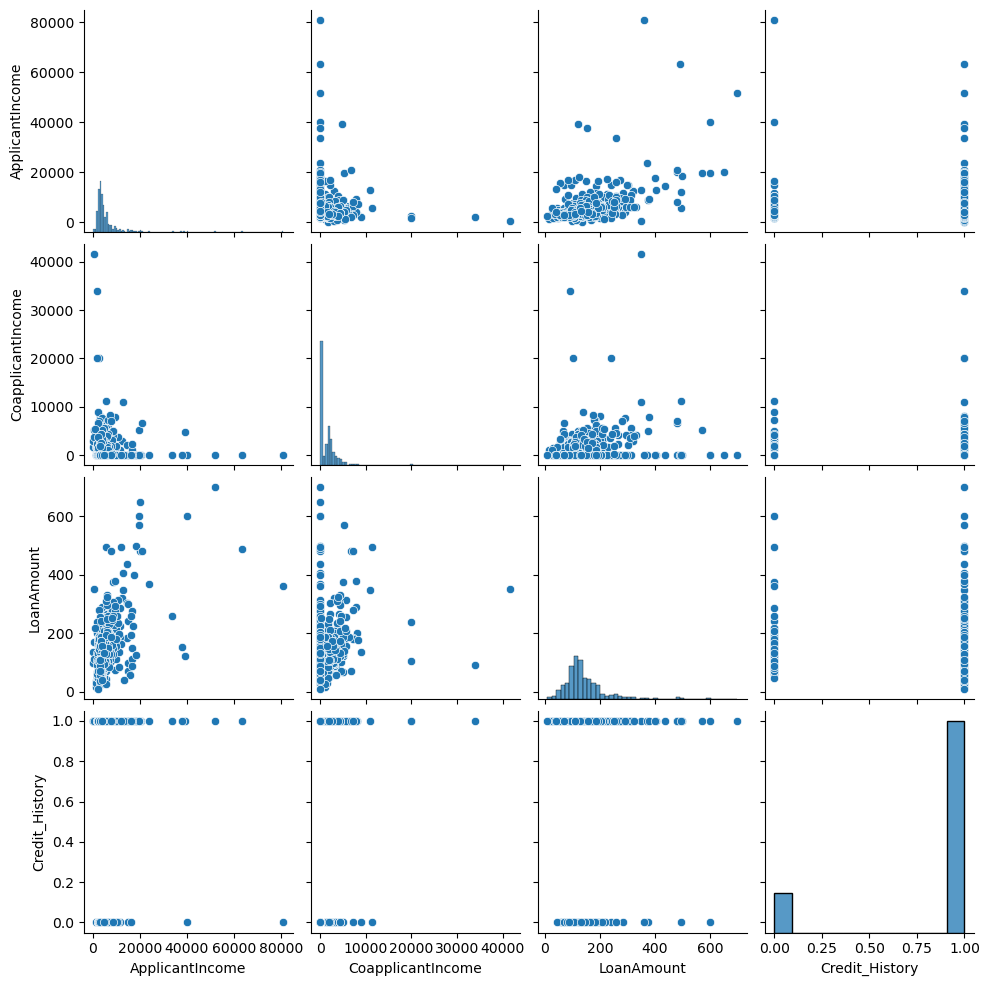

In [236]:
sns.pairplot(df[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Credit_History']])
plt.show()

<Axes: xlabel='Gender'>

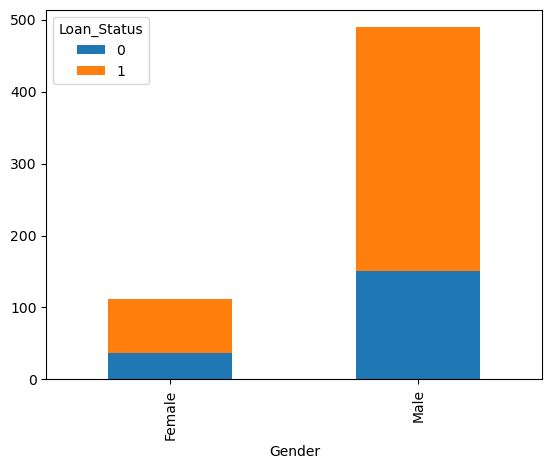

In [237]:
pd.crosstab(df['Gender'], df['Loan_Status']).plot(kind='bar', stacked=True)

In [247]:
# - Created two normalized Oracle SQL tables: LOAN_CASE and LOAN_STATUS
# - Connected Oracle SQL to Python using the oracledb package
# - Loaded SQL query results directly into Pandas for analysis
# - Conducted EDA, feature engineering, and predictive modeling

In [248]:
!pip install cx_Oracle

In [249]:
import cx_Oracle
print("Connection module loaded successfully!")

Connection module loaded successfully!


In [250]:
conn = cx_Oracle.connect("system/cscorner@localhost/XEPDB1")
print(conn.version)

21.3.0.0.0


In [253]:
!pip install oracledb

In [254]:
import oracledb
import pandas as pd

# Connect using your Oracle DB credentials
conn = oracledb.connect(
    user="loanuser",            # your Oracle username
    password="loanpass",        # your Oracle password
    dsn="localhost/XEPDB1"      # your Oracle DSN (for Oracle 21c XE)
)


In [256]:
df = pd.read_sql("SELECT * FROM LOAN_CASE FETCH FIRST 5 ROWS ONLY", conn)
print(df.head())


    LOAN_ID  GENDER MARRIED DEPENDENTS     EDUCATION SELF_EMPLOYED  \
0  LP001601    Male      No         3+      Graduate            No   
1  LP001607  Female      No          0  Not Graduate            No   
2  LP001611    Male     Yes          1      Graduate            No   
3  LP001613  Female      No          0      Graduate            No   
4  LP001622    Male     Yes          2      Graduate            No   

   APPLICANTINCOME  COAPPLICANTINCOME  LOANAMOUNT  LOAN_AMOUNT_TERM  \
0             4243               4123         157             360.0   
1                0               1760         180             360.0   
2             1516               2900          80               NaN   
3             1762               2666         104             360.0   
4              724               3510         213             360.0   

   CREDIT_HISTORY PROPERTY_AREA  
0             NaN     Semiurban  
1             1.0     Semiurban  
2             0.0         Rural  
3             0.

C:\Users\diont\AppData\Local\Temp\ipykernel_16824\2052935172.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM LOAN_CASE FETCH FIRST 5 ROWS ONLY", conn)


In [258]:
df2 = pd.read_sql("SELECT * FROM LOAN_STATUS FETCH FIRST 5 ROWS ONLY", conn)
print(df2.head())


    LOAN_ID  GENDER MARRIED DEPENDENTS     EDUCATION SELF_EMPLOYED  \
0  LP001391    Male     Yes          0  Not Graduate            No   
1  LP001392  Female      No          1      Graduate           Yes   
2  LP001398    Male      No          0      Graduate          None   
3  LP001401    Male     Yes          1      Graduate            No   
4  LP001404  Female     Yes          0      Graduate            No   

   APPLICANTINCOME  COAPPLICANTINCOME  LOANAMOUNT  LOAN_AMOUNT_TERM  \
0             3572               4114       152.0               NaN   
1             7451                  0         NaN             360.0   
2             5050                  0       118.0             360.0   
3            14583                  0       185.0             180.0   
4             3167               2283       154.0             360.0   

   CREDIT_HISTORY PROPERTY_AREA LOAN_STATUS  
0               0         Rural           N  
1               1     Semiurban           Y  
2             

C:\Users\diont\AppData\Local\Temp\ipykernel_16824\3950665750.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df2 = pd.read_sql("SELECT * FROM LOAN_STATUS FETCH FIRST 5 ROWS ONLY", conn)


In [260]:
def connect_oracle():
    return oracledb.connect(
        user="loanuser",
        password="loanpass",
        dsn="localhost/XEPDB1"
    )

# Usage
conn = connect_oracle()
df = pd.read_sql("SELECT * FROM LOAN_CASE", conn)
conn.close()


C:\Users\diont\AppData\Local\Temp\ipykernel_16824\121479135.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM LOAN_CASE", conn)


In [261]:
import pandas as pd
import oracledb
import matplotlib.pyplot as plt
import seaborn as sns

# Connect to Oracle
conn = oracledb.connect(
    user="loanuser",
    password="loanpass",
    dsn="localhost/XEPDB1"
)

# Load data from Oracle
df = pd.read_sql("SELECT * FROM LOAN_CASE", conn)
conn.close()


C:\Users\diont\AppData\Local\Temp\ipykernel_16824\3593019991.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM LOAN_CASE", conn)


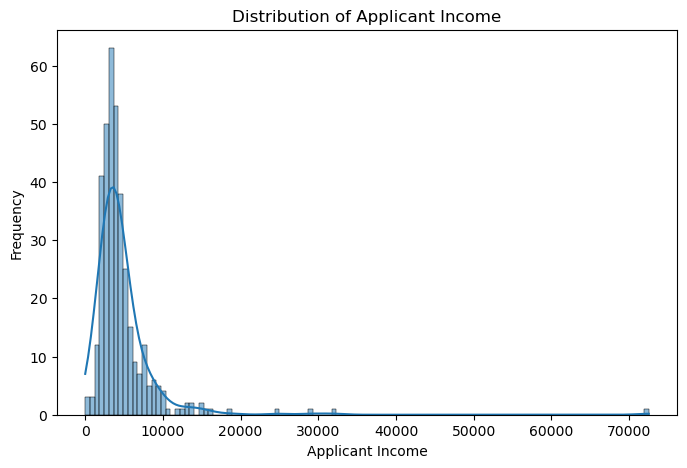

In [262]:
plt.figure(figsize=(8, 5))
sns.histplot(df['APPLICANTINCOME'], kde=True)
plt.title('Distribution of Applicant Income')
plt.xlabel('Applicant Income')
plt.ylabel('Frequency')
plt.show()

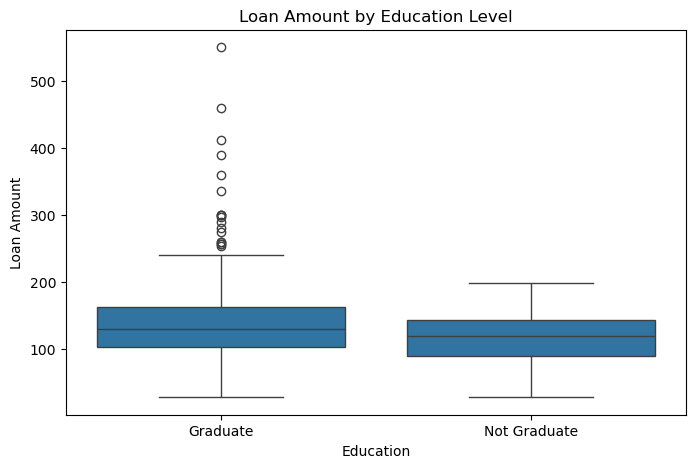

In [263]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='EDUCATION', y='LOANAMOUNT', data=df)
plt.title('Loan Amount by Education Level')
plt.xlabel('Education')
plt.ylabel('Loan Amount')
plt.show()

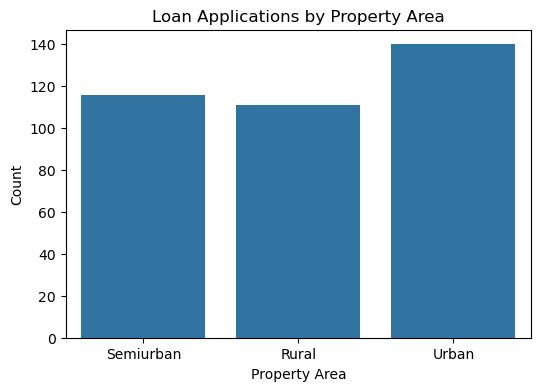

In [264]:
plt.figure(figsize=(6, 4))
sns.countplot(x='PROPERTY_AREA', data=df)
plt.title('Loan Applications by Property Area')
plt.xlabel('Property Area')
plt.ylabel('Count')
plt.show()

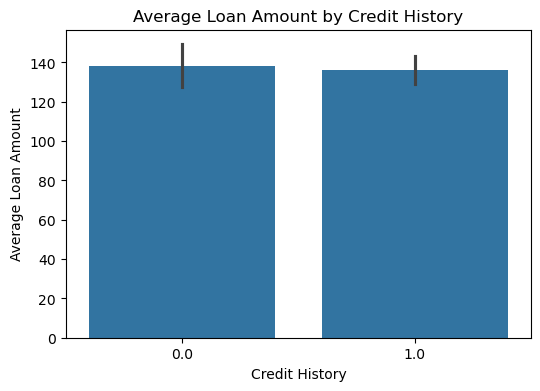

In [265]:
plt.figure(figsize=(6, 4))
sns.barplot(x='CREDIT_HISTORY', y='LOANAMOUNT', data=df, estimator='mean')
plt.title('Average Loan Amount by Credit History')
plt.xlabel('Credit History')
plt.ylabel('Average Loan Amount')
plt.show()

In [266]:
print(loan_status.columns.tolist())


['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


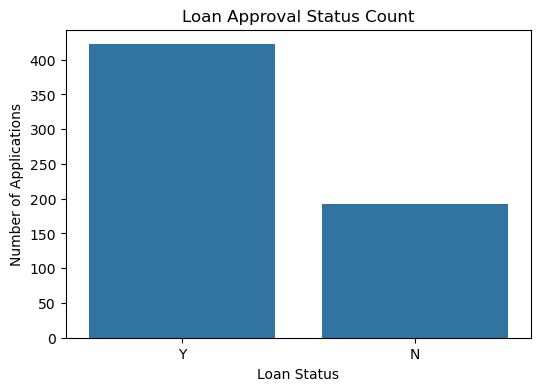

In [267]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Loan_Status', data=loan_status)
plt.title('Loan Approval Status Count')
plt.xlabel('Loan Status')
plt.ylabel('Number of Applications')
plt.show()


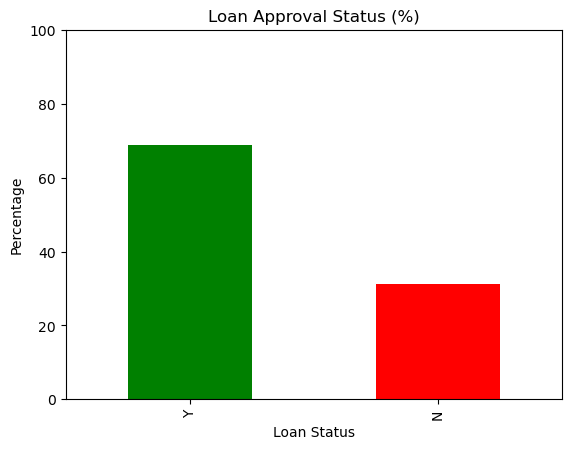

In [268]:
loan_counts = loan_status['Loan_Status'].value_counts(normalize=True) * 100
loan_counts.plot(kind='bar', color=['green', 'red'])
plt.title('Loan Approval Status (%)')
plt.ylabel('Percentage')
plt.xlabel('Loan Status')
plt.ylim(0, 100)
plt.show()

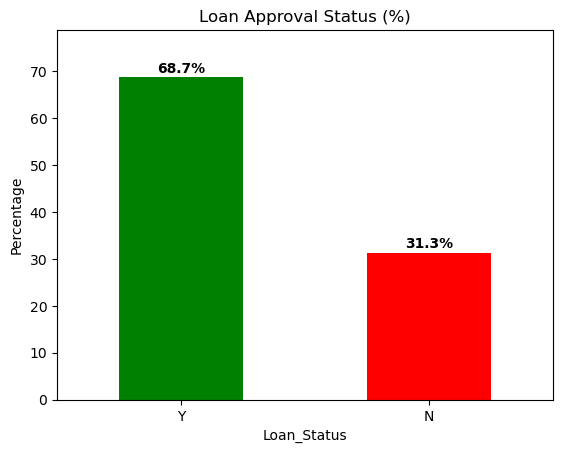

In [269]:
import matplotlib.pyplot as plt

# Calculate the normalized loan status counts
loan_counts = loan_status['Loan_Status'].value_counts(normalize=True) * 100

# Create the bar chart
ax = loan_counts.plot(kind='bar', color=['green', 'red'])

# Annotate each bar with the percentage
for i, v in enumerate(loan_counts):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.title('Loan Approval Status (%)')
plt.ylabel('Percentage')
plt.ylim(0, max(loan_counts) + 10)  # add space for labels
plt.xticks(rotation=0)
plt.show()


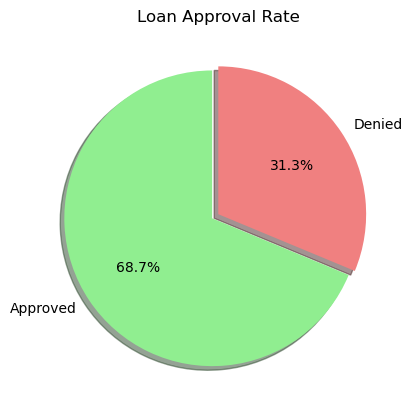

In [272]:
loan_status['Loan_Status'].value_counts().plot.pie(
    autopct='%1.1f%%', 
    startangle=90, 
    colors=['lightgreen', 'lightcoral'],
    labels=['Approved', 'Denied'],
    explode=(0.05, 0),
    shadow=True
)
plt.title('Loan Approval Rate')
plt.ylabel('')  # Removes the y-axis label
plt.show()

In [273]:
# Observations from Loan Status Visualizations:
# The dataset is imbalanced, with ~70% approvals.
# Modeling may require balancing techniques (SMOTE, undersampling).
# Visuals communicate important trends in one glance — key for stakeholders.


In [274]:
# Show missing value count per column
print(df.isnull().sum())

print((df.isnull().mean() * 100).round(1))


LOAN_ID               0
GENDER               11
MARRIED               0
DEPENDENTS           10
EDUCATION             0
SELF_EMPLOYED        23
APPLICANTINCOME       0
COAPPLICANTINCOME     0
LOANAMOUNT            5
LOAN_AMOUNT_TERM      6
CREDIT_HISTORY       29
PROPERTY_AREA         0
dtype: int64
LOAN_ID              0.0
GENDER               3.0
MARRIED              0.0
DEPENDENTS           2.7
EDUCATION            0.0
SELF_EMPLOYED        6.3
APPLICANTINCOME      0.0
COAPPLICANTINCOME    0.0
LOANAMOUNT           1.4
LOAN_AMOUNT_TERM     1.6
CREDIT_HISTORY       7.9
PROPERTY_AREA        0.0
dtype: float64


In [275]:
df['GENDER'] = df['GENDER'].fillna(df['GENDER'].mode()[0])
df['DEPENDENTS'] = df['DEPENDENTS'].fillna(df['DEPENDENTS'].mode()[0])
df['SELF_EMPLOYED'] = df['SELF_EMPLOYED'].fillna(df['SELF_EMPLOYED'].mode()[0])
df['LOANAMOUNT'] = df['LOANAMOUNT'].fillna(df['LOANAMOUNT'].median())
df['LOAN_AMOUNT_TERM'] = df['LOAN_AMOUNT_TERM'].fillna(df['LOAN_AMOUNT_TERM'].mode()[0])
df['CREDIT_HISTORY'] = df['CREDIT_HISTORY'].fillna(df['CREDIT_HISTORY'].mode()[0])


In [278]:
# Show missing value count per column
print(df.isnull().sum())


print((df.isnull().mean() * 100).round(1))


LOAN_ID              0
GENDER               0
MARRIED              0
DEPENDENTS           0
EDUCATION            0
SELF_EMPLOYED        0
APPLICANTINCOME      0
COAPPLICANTINCOME    0
LOANAMOUNT           0
LOAN_AMOUNT_TERM     0
CREDIT_HISTORY       0
PROPERTY_AREA        0
dtype: int64
LOAN_ID              0.0
GENDER               0.0
MARRIED              0.0
DEPENDENTS           0.0
EDUCATION            0.0
SELF_EMPLOYED        0.0
APPLICANTINCOME      0.0
COAPPLICANTINCOME    0.0
LOANAMOUNT           0.0
LOAN_AMOUNT_TERM     0.0
CREDIT_HISTORY       0.0
PROPERTY_AREA        0.0
dtype: float64


In [279]:
# Show missing value count per column
print(df.isnull().sum())

# Optional: Check missing values in loan_status
print(loan_status.isnull().sum())

LOAN_ID              0
GENDER               0
MARRIED              0
DEPENDENTS           0
EDUCATION            0
SELF_EMPLOYED        0
APPLICANTINCOME      0
COAPPLICANTINCOME    0
LOANAMOUNT           0
LOAN_AMOUNT_TERM     0
CREDIT_HISTORY       0
PROPERTY_AREA        0
dtype: int64
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [281]:
loan_status.fillna({
    'Gender': loan_status['Gender'].mode()[0],
    'Married': loan_status['Married'].mode()[0],          
    'Dependents': loan_status['Dependents'].mode()[0],
    'Self_Employed': loan_status['Self_Employed'].mode()[0],
    'LoanAmount': loan_status['LoanAmount'].median(),
    'Loan_Amount_Term': loan_status['Loan_Amount_Term'].mode()[0],
    'Credit_History': loan_status['Credit_History'].mode()[0]
}, inplace=True)

In [282]:
# Show missing value count per column
print(df.isnull().sum())

# Optional: Check missing values in loan_status
print(loan_status.isnull().sum())

LOAN_ID              0
GENDER               0
MARRIED              0
DEPENDENTS           0
EDUCATION            0
SELF_EMPLOYED        0
APPLICANTINCOME      0
COAPPLICANTINCOME    0
LOANAMOUNT           0
LOAN_AMOUNT_TERM     0
CREDIT_HISTORY       0
PROPERTY_AREA        0
dtype: int64
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [283]:
### Data Cleaning:
# - Detected and handled missing values using pandas
# - Replaced missing numeric features with median values
# - Filled missing categorical features using mode
# - Ensured no nulls before exporting to Power BI for visualization


In [290]:
df.to_csv("loan_case_cleaned.csv", index=False)
loan_status.to_csv("loan_status_cleaned.csv", index=False)